In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [48]:
df = pd.read_csv("dataset.csv")

In [49]:
#Basic EDA analysis for overview of the dataset

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Internet              14003 non-null  int64
 5   Gender                14003 non-null  int64
 6   Age                   14003 non-null  int64
 7   LearningStyle         14003 non-null  int64
 8   OnlineCourses         14003 non-null  int64
 9   Discussions           14003 non-null  int64
 10  AssignmentCompletion  14003 non-null  int64
 11  ExamScore             14003 non-null  int64
 12  EduTech               14003 non-null  int64
 13  FinalGrade            14003 non-null  int64
dtypes: int64(14)
memory usage: 1.5 MB


,StudyHours,Attendance,Resources,Extracurricular,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,3.000000


In [50]:
#data cleaning for missing valued and null values

df = df.dropna()


In [51]:
#defining varibles

X = df.drop("FinalGrade",axis=1)   
y = df["FinalGrade"]

In [52]:
#basic ML model declaration

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # for multi-class balance
)

In [53]:
#applying the Decision tree concept

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       766
           1       1.00      1.00      1.00       662
           2       1.00      1.00      1.00       724
           3       1.00      1.00      1.00       649

    accuracy                           1.00      2801
   macro avg       1.00      1.00      1.00      2801
weighted avg       1.00      1.00      1.00      2801



In [54]:
#applying the random forest concept

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       766
           1       1.00      1.00      1.00       662
           2       1.00      1.00      1.00       724
           3       1.00      1.00      1.00       649

    accuracy                           1.00      2801
   macro avg       1.00      1.00      1.00      2801
weighted avg       1.00      1.00      1.00      2801



In [55]:
#comparing the train and test accuracy by overfitting

print("Decision Tree Train Accuracy:",dt.score(X_train,y_train))
print("Decision Tree Test Accuracy:",dt.score(X_test,y_test))

print("Random Forest Train Accuracy:",rf.score(X_train,y_train))
print("Random Forest Train Accuracy:",rf.score(X_test,y_test))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 1.0
Random Forest Train Accuracy: 1.0
Random Forest Train Accuracy: 1.0


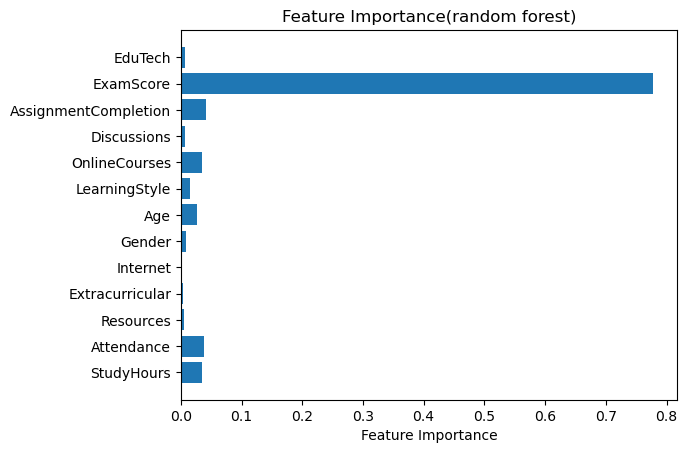

In [56]:
#Time for data visualization for better analysis

import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features,importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance(random forest)")
plt.show()

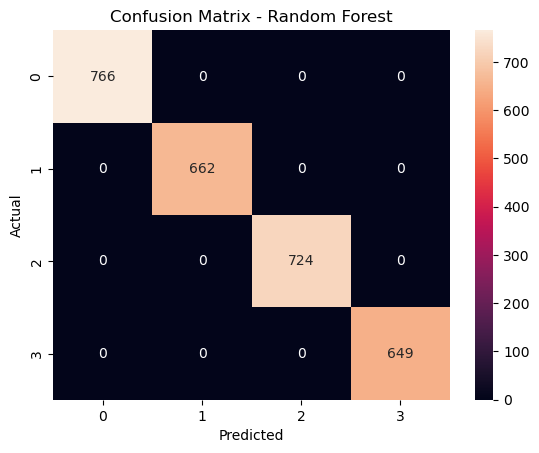

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred_rf)

plt.figure()
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
study_hours = float(input("Enter Study Hours:"))
attendance = float(input(" Enter Attendance :"))
resources = float(input("Enter Resources Score:"))
extracurricular = float(input("Enter extracurricular score:"))
internet=float(input("Enter Internet access score:"))
gender=float(input("Enter Gender(0/1) :"))
age = float(input("Enter Age:"))
learning_style = float(input("Enter Learning style score :"))
online_courses = float(input("Enter Online courses count:"))
discussion=float(input("Enter Discussion Participation Score:"))
assignment_completion = float(input(" Enter Assignment Completion Score:"))
exam_score = float(input("Enter Exam Score:"))
edutech = float(input("Enter Edutech usage score :"))



Enter Study Hours: 6
 Enter Attendance : 85
Enter Resources Score: 3
Enter extracurricular score: 2
Enter Internet access score: 1
Enter Gender(0/1) : 1
Enter Age: 1
Enter Learning style score : 2
Enter Online courses count: 1
Enter Discussion Participation Score: 3
 Enter Assignment Completion Score: 4
Enter Exam Score: 45
Enter Edutech usage score : 3


In [63]:
user_data = np.array([[
    study_hours,attendance,resources,extracurricular,internet,
    gender,age,learning_style,online_courses,discussion,assignment_completion,
    exam_score,edutech ]])

user_df = pd.DataFrame(user_data, columns=X.columns)

In [64]:
prediction = rf.predict(user_df)

In [65]:
grade_map = {
    0:"poor",
    1:"Average",
    2:"Good",
    3:"Excellent"
}

print("Predicted Final Grade :",grade_map[prediction[0]])

Predicted Final Grade : Excellent
